In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Tabla1.csv to Tabla1.csv
Saving Tabla2.csv to Tabla2.csv


In [ ]:
def leer_csv(ruta):
    puntos = []
    with open(ruta, "r") as f:
        for linea in f:
            x, y = linea.strip().split(",")
            puntos.append((float(x), float(y)))
    return puntos

puntos_tabla1 = leer_csv("Tabla1.csv")
puntos_tabla2 = leer_csv("Tabla2.csv")

# Importe de librerias


In [ ]:
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from scipy.optimize import curve_fit

# Manejo de los archivos.
Se leen los archivos csv, y se guardan en tuplas dentro de un arreglo.

# Gráfico de los puntos de cada archivo.
2. Inciso 1.a: Análisis Visual (Datos Crudos)




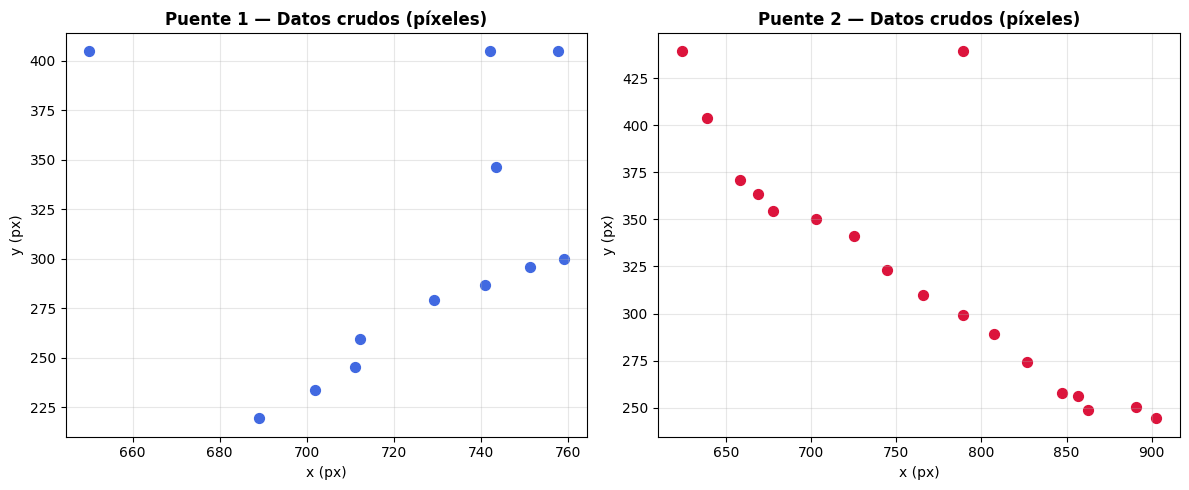

In [ ]:
def graficar_puntos(puntos1, puntos2):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  x_t1, y_t1 = zip(*puntos_tabla1)
  axes[0].scatter(x_t1, y_t1, color="royalblue", s=50)
  axes[0].set_title("Puente 1 — Datos crudos (píxeles)", fontweight="bold")
  axes[0].set_xlabel("x (px)")
  axes[0].set_ylabel("y (px)")
  axes[0].grid(True, alpha=0.3)

  x_t2, y_t2 = zip(*puntos_tabla2)
  axes[1].scatter(x_t2, y_t2, color="crimson", s=50)
  axes[1].set_title("Puente 2 — Datos crudos (píxeles)", fontweight="bold")
  axes[1].set_xlabel("x (px)")
  axes[1].set_ylabel("y (px)")
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()
  plt.close()

graficar_puntos(puntos_tabla1, puntos_tabla2)

# Limpieza y transformación de los datos.

Se realizan correcciones correspondientes a los datos, se toma un punto P1 como centro de coordenadas y se pasan las coordenadas de los puntos digitalizados a unidades de distancia, sabiendo que los puentes tienen una luz a 20 metros.

In [ ]:
def transformar_a_metros(puntos, idx_p1, idx_p2):
    p1_x, p1_y = puntos[idx_p1]
    p2_x, p2_y = puntos[idx_p2]

    dist_px = math.sqrt((p2_x - p1_x) ** 2 + (p2_y - p1_y) ** 2)
    factor = 20.0 / dist_px

    resultado = []
    for x, y in puntos:
        nuevo_x = (x - p1_x) * factor
        nuevo_y = (p1_y - y) * factor
        resultado.append((nuevo_x, nuevo_y))

    resultado_final = sorted(resultado, key=lambda p: p[0])
    return resultado_final, resultado

p1, p1_m = transformar_a_metros(puntos_tabla1, 0, 1)
p2, p2_m = transformar_a_metros(puntos_tabla2, 0, 1)

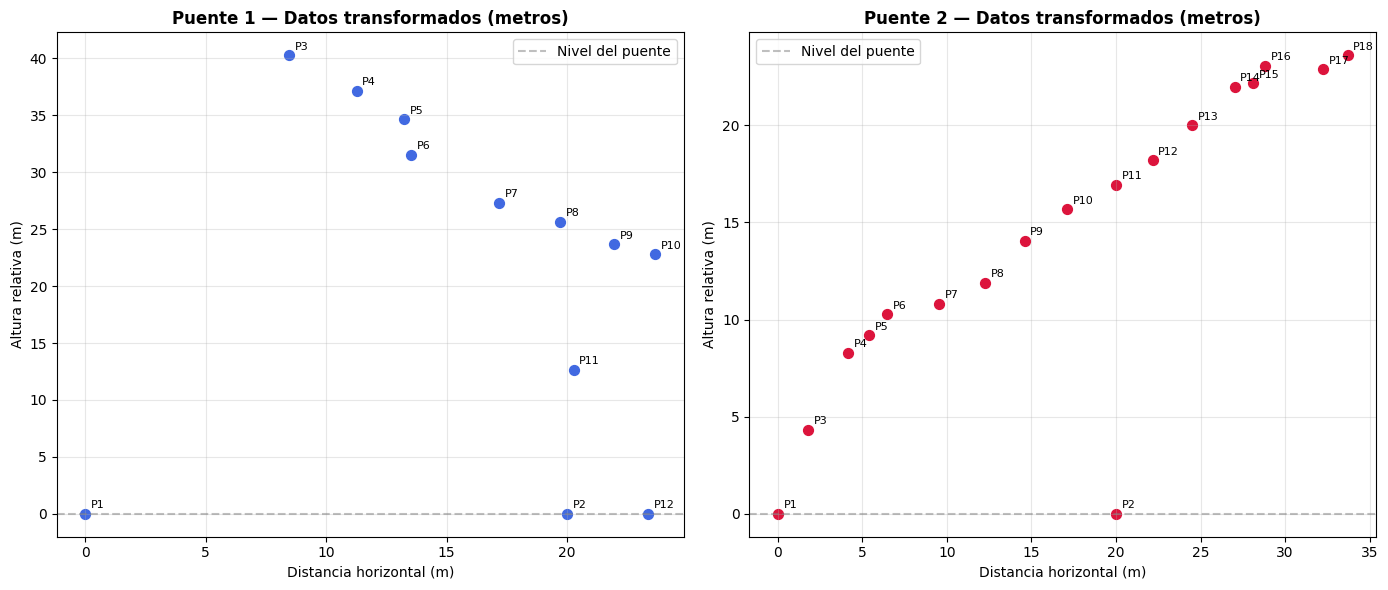

In [ ]:
def graficar_transformacion(p1_m, p2_m):
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  x_r1, y_r1 = zip(*p1_m)
  axes[0].scatter(x_r1, y_r1, color="royalblue", s=50)
  for i, (x, y) in enumerate(zip(x_r1, y_r1)):
      axes[0].annotate(
          f"P{i+1}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8
      )
  axes[0].set_title("Puente 1 — Datos transformados (metros)", fontweight="bold")
  axes[0].set_xlabel("Distancia horizontal (m)")
  axes[0].set_ylabel("Altura relativa (m)")
  axes[0].axhline(0, color="gray", ls="--", alpha=0.5, label="Nivel del puente")
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  x_r2, y_r2 = zip(*p2_m)
  axes[1].scatter(x_r2, y_r2, color="crimson", s=50)
  for i, (x, y) in enumerate(zip(x_r2, y_r2)):
      axes[1].annotate(
          f"P{i+1}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8
      )
  axes[1].set_title("Puente 2 — Datos transformados (metros)", fontweight="bold")
  axes[1].set_xlabel("Distancia horizontal (m)")
  axes[1].set_ylabel("Altura relativa (m)")
  axes[1].axhline(0, color="gray", ls="--", alpha=0.5, label="Nivel del puente")
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()
  plt.close()

graficar_transformacion(p1_m, p2_m)

# Función partida
Interpolacion para el puente 1, 3 tramos, dos lineales y una funcion tomando los puntos centrales relevados.

Los tramos lineales son para las margenes P1 a P3 y P10 a P11. Y en los puntos centrales se uso Langrange


In [ ]:

def lagrange_base(i, xi, x_nodos):
    resultado = 1.0
    for j in range(len(x_nodos)):
        if j != i:
            resultado *= (xi - x_nodos[j]) / (x_nodos[i] - x_nodos[j])
    return resultado


def lagrange_evaluar(xi, x_nodos, y_nodos):
    return sum(y_nodos[i] * lagrange_base(i, xi, x_nodos) for i in range(len(x_nodos)))

In [ ]:
def construir_puente1(puntos_metros):
    x_all = np.array([p[0] for p in puntos_metros])
    y_all = np.array([p[1] for p in puntos_metros])

    IDX_P1 = 0
    IDX_P3 = 2
    IDX_P10 = 9
    IDX_P11 = 10

    x_P1, y_P1 = x_all[IDX_P1], y_all[IDX_P1]
    x_P3, y_P3 = x_all[IDX_P3], y_all[IDX_P3]
    x_P10, y_P10 = x_all[IDX_P10], y_all[IDX_P10]
    x_P11, y_P11 = x_all[IDX_P11], y_all[IDX_P11]


    idx_sel = [2,3, 4,  6, 7,8, 9]
    x_lag = x_all[idx_sel]
    y_lag = y_all[idx_sel]

    # Se usa lagrange de Scipy para comparar con el que fue programado por nosotros.
    pol_scipy = lagrange(x_lag, y_lag)

    def f_top(x):
        if x <= x_P3:
            if x_P3 == x_P1:
                return y_P1
            return y_P1 + (y_P3 - y_P1) * (x - x_P1) / (x_P3 - x_P1)
        else:
            return lagrange_evaluar(x, x_lag, y_lag)

    f_top_vec = np.vectorize(f_top)

    def f_bottom(x):
        if x_P10 == x_P11:
            return y_P10
        return y_P11 + (y_P10 - y_P11) * (x - x_P11) / (x_P10 - x_P11)

    f_bottom_vec = np.vectorize(f_bottom)

    area_trapecio = 0.5 * (y_P10 + y_P11) * (x_P10 - x_P11)

    info = {
        "x_P1": x_P1,
        "x_P3": x_P3,
        "x_P10": x_P10,
        "x_P11": x_P11,
        "x_lag": x_lag,
        "y_lag": y_lag,
        "f_bottom": f_bottom_vec,
        "pol_scipy": pol_scipy,
        "area_trapecio": area_trapecio,
        "x_all": x_all,
        "y_all": y_all,
    }
    return f_top_vec, info


f1, info1 = construir_puente1(p1_m)

GRAFICO 1


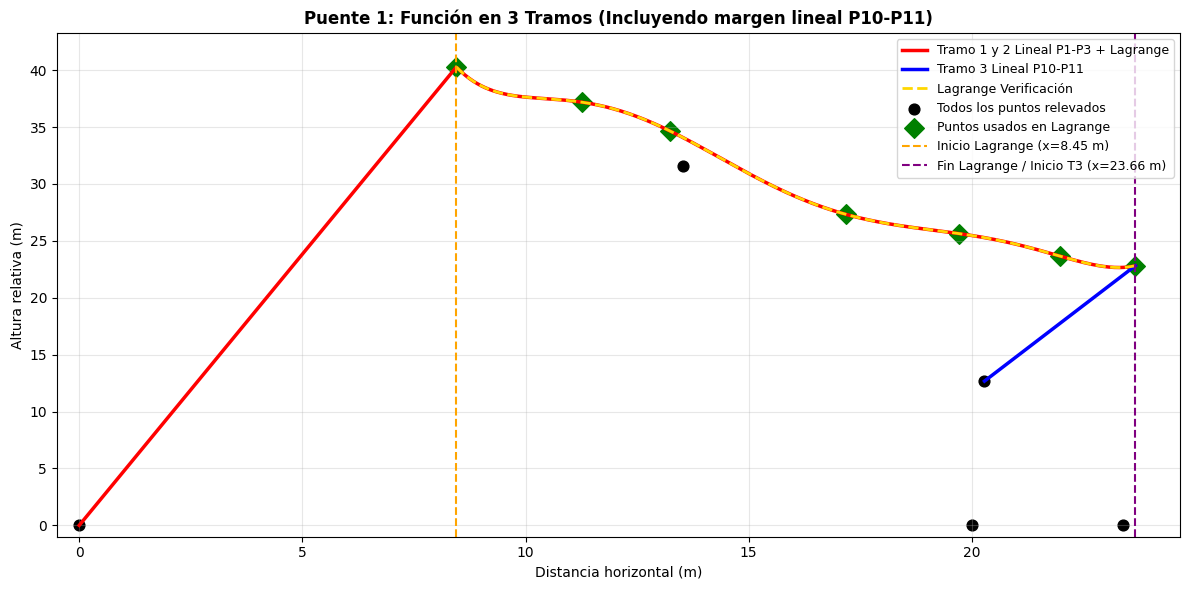

In [ ]:

x_plot_top = np.linspace(info1["x_P1"], info1["x_P10"], 800)
y_plot_top = f1(x_plot_top)
x_plot_bot = np.linspace(info1["x_P11"], info1["x_P10"], 100)
y_plot_bot = info1["f_bottom"](x_plot_bot)
plt.figure(figsize=(12, 6))


x_plot_scipy = np.linspace(info1["x_P3"], info1["x_P10"], 400)
y_plot_scipy = info1["pol_scipy"](x_plot_scipy)

plt.plot(
    x_plot_top, y_plot_top, "r-", lw=2.5, label="Tramo 1 y 2 Lineal P1-P3 + Lagrange"
)
plt.plot(
    x_plot_bot, y_plot_bot, "b-", lw=2.5, label="Tramo 3 Lineal P10-P11"
)
plt.plot(x_plot_scipy, y_plot_scipy, color="gold", ls="--", lw=2, label="Lagrange Verificación")
plt.scatter(
    info1["x_all"],
    info1["y_all"],
    color="black",
    s=60,
    label="Todos los puntos relevados",
)
plt.scatter(
    info1["x_lag"],
    info1["y_lag"],
    color="green",
    s=100,
    marker="D",
    label="Puntos usados en Lagrange",
)
plt.axvline(
    info1["x_P3"],
    color="orange",
    ls="--",
    lw=1.5,
    label=f"Inicio Lagrange (x={info1['x_P3']:.2f} m)",
)
plt.axvline(
    info1["x_P10"],
    color="purple",
    ls="--",
    lw=1.5,
    label=f"Fin Lagrange / Inicio T3 (x={info1['x_P10']:.2f} m)",
)
plt.title(
    "Puente 1: Función en 3 Tramos (Incluyendo margen lineal P10-P11)",
    fontweight="bold",
)
plt.xlabel("Distancia horizontal (m)")
plt.ylabel("Altura relativa (m)")
plt.xlim(info1["x_P1"] - 0.5, max(info1["x_P10"], info1["x_all"][-1]) + 1)
plt.ylim(-1, max(info1["y_all"]) + 3)
plt.legend(fontsize=9, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()



AJUSTE 2 : PARA EL PUJENTE 2 POR CUADRADOS MINIMOS
1. 2 tramos de ecuaciones cuadráticas negativas (1er tramo
hasta el punto P8 incluído, el 2do tramo comienza en el
P8 y termina con el P18 incuído) + 1 función lineal
interpolada
2. 1 ecuación cuadrática negativa + 1 función lineal
interpolada.
3. Para cada uno de los ajustes, calcular el error cuadrático y
quedarse con la función que menor error presente.

In [ ]:


def cuadratica_neg(x, a, b, c):
    return -abs(a) * x**2 + b * x + c


def construir_puente2(puntos_metros):
    x2 = np.array([p[0] for p in puntos_metros])
    y2 = np.array([p[1] for p in puntos_metros])


    IDX_P8 = 7
    IDX_P10 = 1
    IDX_P18 = 17

    idx_a1 = [i for i in range(0, IDX_P8 + 1)]
    x_a1, y_a1 = x2[idx_a1], y2[idx_a1]

    idx_a2 = [i for i in range(IDX_P8, IDX_P18 + 1) if i not in [IDX_P10]]
    x_a2, y_a2 = x2[idx_a2], y2[idx_a2]

    coef_a1, _ = curve_fit(cuadratica_neg, x_a1, y_a1, maxfev=5000)
    coef_a2, _ = curve_fit(cuadratica_neg, x_a2, y_a2, maxfev=5000)

    def modelo_a(x):
        if x <= x2[IDX_P8]:
            return float(cuadratica_neg(x, *coef_a1))
        else:
            return float(cuadratica_neg(x, *coef_a2))

    idx_comp = [i for i in range(0, IDX_P18 + 1) if i not in [IDX_P10]]
    x_comp, y_comp = x2[idx_comp], y2[idx_comp]
    coef_b, _ = curve_fit(cuadratica_neg, x_comp, y_comp, maxfev=5000)

    def modelo_b(x):
        return float(cuadratica_neg(x, *coef_b))

    y_pred_a = np.array([modelo_a(xi) for xi in x_comp])
    y_pred_b = np.array([modelo_b(xi) for xi in x_comp])
    err_a = float(np.sum((y_comp - y_pred_a) ** 2))
    err_b = float(np.sum((y_comp - y_pred_b) ** 2))

    if err_a <= err_b:
        f_tablero = np.vectorize(modelo_a)
        nombre = "Modelo A (2 cuadráticas)"
    else:
        f_tablero = np.vectorize(modelo_b)
        nombre = "Modelo B (1 cuadrática)"

    def f_tirante(x):
        pend = (y2[IDX_P18] - y2[IDX_P10]) / (x2[IDX_P18] - x2[IDX_P10])
        return y2[IDX_P10] + pend * (x - x2[IDX_P10])

    info = {
        "nombre": nombre,
        "err_a": err_a,
        "err_b": err_b,
        "x_P8": x2[IDX_P8],
        "x_P10": x2[IDX_P10],
        "y_P10": y2[IDX_P10],
        "x_P18": x2[IDX_P18],
        "x_comp": x_comp,
        "y_comp": y_comp,
    }
    return f_tablero, f_tirante, info

f_tab2, f_tir2, info2 = construir_puente2(p2_m)

# Grafico puente 2

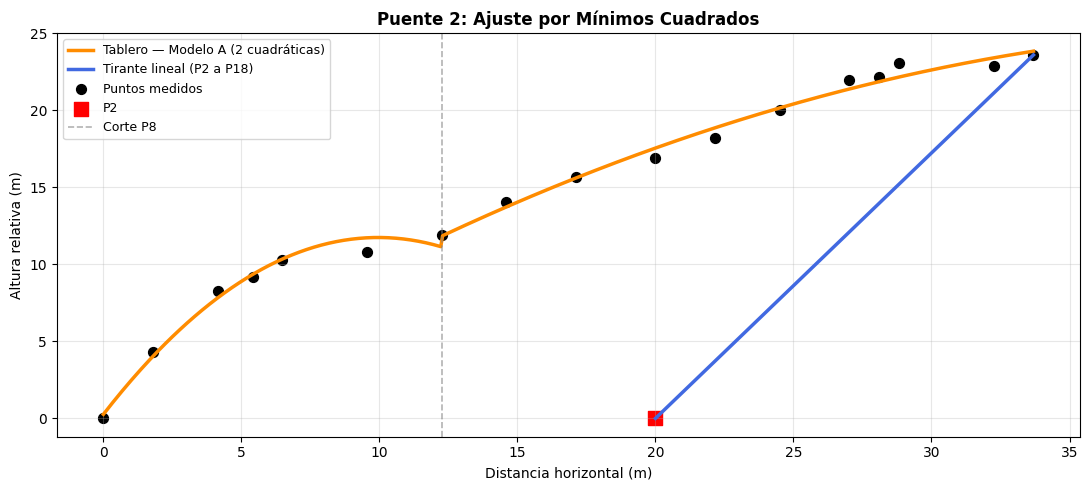

In [ ]:
x_tab_plot = np.linspace(0, info2["x_P18"], 500)
y_tab_plot = f_tab2(x_tab_plot)
x_tir_plot = np.linspace(info2["x_P10"], info2["x_P18"], 200)
y_tir_plot = np.array([f_tir2(v) for v in x_tir_plot])

plt.figure(figsize=(11, 5))
plt.plot(
    x_tab_plot,
    y_tab_plot,
    color="darkorange",
    lw=2.5,
    label=f'Tablero — {info2["nombre"]}',
)
plt.plot(
    x_tir_plot,
    y_tir_plot,
    color="royalblue",
    lw=2.5,
    label="Tirante lineal (P2 a P18)",
)
plt.scatter(
    info2["x_comp"],
    info2["y_comp"],
    color="black",
    s=50,
    label="Puntos medidos",
)
plt.scatter(
    [info2["x_P10"]],
    [info2["y_P10"]],
    color="red",
    s=100,
    marker="s",
    label="P2",
)
plt.axvline(info2["x_P8"], ls="--", color="gray", alpha=0.6, lw=1.2, label="Corte P8")

plt.title("Puente 2: Ajuste por Mínimos Cuadrados", fontweight="bold")
plt.xlabel("Distancia horizontal (m)")
plt.ylabel("Altura relativa (m)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.show()
plt.close()

# Integracion por simpson 3/8
Integrar las áreas. Para aplicar los métodos se debe tomar valores
redondos para los cambios de funciones

In [ ]:
def simpson_38(f, a, b, h=1.0):
    n = int(round((b - a) / h))
    if n % 3 != 0:
        n = n + (3 - n % 3)
    h_real = (b - a)/n
    x_nodos = np.linspace(a, b, n + 1)
    y_nodos = np.array([abs(f(xi)) for xi in x_nodos])

    suma = y_nodos[0] + y_nodos[-1]
    for i in range(1, n):
        if i % 3 == 0:
            suma += 2 * y_nodos[i]
        else:
            suma += 3 * y_nodos[i]
    return (3 * h_real / 8) * suma, n

a1_int = info1["x_P1"]
b1_int = info1["x_P10"]
area_top_s38, n_s38_p1 = simpson_38(f1, a1_int, b1_int, h=1.0)
area_s38_p1 = area_top_s38 - info1["area_trapecio"]
a2_int = 0.0
b2_int = info2["x_P18"]

area_s38_p2, n_s38_p2 = simpson_38(f_tab2, a2_int, b2_int, h=1.0)
print(f"{'Simpson 3/8 (h=1 m)':<35} {area_s38_p1} {area_s38_p2}")

Simpson 3/8 (h=1 m)                 570.5066173012053 508.8524660709295


# Cuadratura Gaussiana
Integrar las áreas. Para aplicar los métodos se debe tomar valores
redondos para los cambios de funciones.


In [ ]:
def cuadratura_gaussiana_3p(f, a, b):
    nodos = np.array([-math.sqrt(3 / 5), 0.0, math.sqrt(3 / 5)])
    pesos = np.array([5 / 9, 8 / 9, 5 / 9])
    x_transf = ((b - a) / 2) * nodos + ((a + b) / 2)
    return ((b - a) / 2) * np.sum(pesos * np.array([abs(f(xi)) for xi in x_transf]))


def cuadratura_gaussiana(f, a, b, h=1.0):
    n = int(round((b - a) / h))
    area = 0.0
    for i in range(n):
        area += cuadratura_gaussiana_3p(f, a + i * h, a + (i + 1) * h)
    return area, n

area_top_cg, n_cg_p1 = cuadratura_gaussiana(f1, a1_int, b1_int, h=1.0)
area_cg_p1 = area_top_cg - info1["area_trapecio"]
area_cg_p2, n_cg_p2 = cuadratura_gaussiana(f_tab2, a2_int, b2_int, h=1.0)
print(f"{'Cuadratura Gaussiana (h=1 m)'} {area_cg_p1} {area_cg_p2}")


Cuadratura Gaussiana (h=1 m) 578.7961425570871 516.5304261081659


| Método             | Área Puente 1 (m²) | Área Puente 2 (m²) |

---


|:-------------------|:-------------------|:-------------------|
| Simpson 3/8        | 570.51             | 508.85             |
| Cuadratura Gaussiana | 578.80             | 516.53             |

# Punto 2


Por medio de distintas campañas, se llega a la estimación de un espesor de
basura medio en el punto de medición igual a 0,40 m. El peso medio de 1 m3 de
residuos flotantes, compuestos principalmente por plásticos y residuos ligeros
suele estar aproximadamente en 800 kg, cuando está húmeda.
Un camión de basura promedio tiene una capacidad de 18 m3 de volumen de
caja. Por otro lado, los caminos tienen una capacidad de carga máxima de 12
toneladas. Definir la cantidad de camiones de basura que serán requeridos para el traslado
de la basura encontrada en función del espesor estimado de la capa de basura,
considerando las limitaciones de volumen y de masa.

La cantidad de camiones necesarios para el primer caso es:  16
La cantidad de camiones necesarios para el segundo caso es:  14


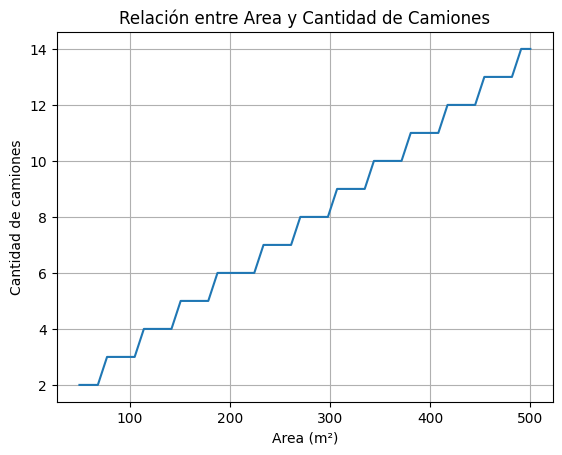

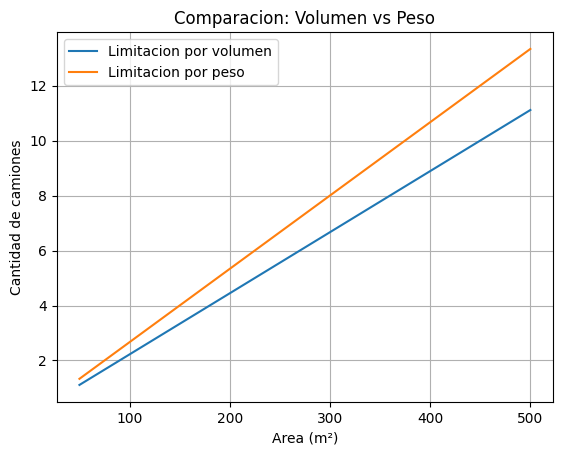

In [ ]:
def calcular_camiones (area):
  espesor = 0.40
  densidad = 800
  capacidad_volumen = 18
  capacidad_peso = 12000

  volumen = area * espesor
  masa = volumen * densidad

  camiones_volumen = volumen / capacidad_volumen
  camiones_peso = masa / capacidad_peso

  camiones_necesarios = math.ceil(max(camiones_volumen, camiones_peso))
  return {
      "total_camiones": camiones_necesarios,
      "camiones_volumen": camiones_volumen,
      "camiones_peso": camiones_peso
  }

areaP1 = (area_s38_p1 + area_cg_p1) / 2
areaP2 = (area_s38_p2 + area_cg_p2) / 2

resultado12_dict = calcular_camiones(areaP1)
resultado22_dict = calcular_camiones(areaP2)

print("La cantidad de camiones necesarios para el primer caso es: ",resultado12_dict["total_camiones"])
print("La cantidad de camiones necesarios para el segundo caso es: ",resultado22_dict["total_camiones"])

import numpy as np
import matplotlib.pyplot as plt

areas = np.linspace(50,500,50)

camiones = [calcular_camiones(a)["total_camiones"] for a in areas]

plt.figure()
plt.plot(areas,camiones)
plt.xlabel("Area (m²)")
plt.ylabel("Cantidad de camiones")
plt.title("Relación entre Area y Cantidad de Camiones")
plt.grid()
plt.show()


camiones_vol = []
camiones_peso = []

for a in areas:
  resultado = calcular_camiones(a)
  camiones_vol.append(resultado["camiones_volumen"])
  camiones_peso.append(resultado["camiones_peso"])

plt.figure()
plt.plot(areas, camiones_vol, label= "Limitacion por volumen")
plt.plot(areas, camiones_peso, label= "Limitacion por peso")

plt.xlabel("Area (m²)")
plt.ylabel("Cantidad de camiones")
plt.title("Comparacion: Volumen vs Peso")
plt.legend()
plt.grid()

plt.show()